# 🛠️ **Functions**

In [1]:
import skimage as ski
from google.colab import drive
import pandas as pd
from skimage import io
from IPython.display import clear_output
from skimage import util
from pathlib import Path
import matplotlib
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import tifffile as tiff
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [2]:
DONE_ASCII = r"""
 ____   ___  _   _  _____
|  _ \ / _ \| \ | || ____|
| | | | | | |  \| ||  _|
| |_| | |_| | |\  || |___
|____/ \___/|_| \_||_____|
"""


In [3]:
pip install tifffile

In [4]:
def normalize(img):
  img=(img-np.min(img))/(np.max(img)-np.min(img))
  return img
def normalize_255(img):
  img=((img-np.min(img))/(np.max(img)-np.min(img)))*255
  return img


In [5]:
%pip install readimc
from readimc import MCDFile, TXTFile

# 📂 **Folder Creation for New Projects**

In [6]:
bool_exist=False
while bool_exist==False:
 name_path = input("Enter the path where the project will be created (if the folder is in 'MyDrive' click on Enter): ")
 path = "/content/gdrive/MyDrive/"
 path += name_path + "/pipeline/"
 bool_exist=os.path.isdir(path)
 if bool_exist==False:
   print("❌ The path does not exist")
 else:
  bool_exist=True
project = input("Enter the project name: ")
if os.path.isdir(path+ project) == False:
    os.mkdir(path + project)
    print("✅ Project created")
else:
    print("✅ project already exist")
path=path+project+"/"
path_img=path+"images/"
path_mcd=path+"images/mcd/"
path_raw=path+"images/raw/"
if os.path.isdir(path_img)==False:
  os.mkdir(path_img)
  print("✅ Folder for images created")
if os.path.isdir(path_mcd)==False:
 os.mkdir(path_mcd)
 print("✅ Folder for MCD images created")
if os.path.isdir(path_raw)==False:
 os.mkdir(path_raw)
 print("✅ Folder for raw TIFF images created")


Enter the path where the project will be created (if the folder is in 'MyDrive' click on Enter): these
Enter the project name: Appendix
✅ project already exist


# 📊 **Images format: MCD --> TIFF**
Execute this block only if you have mcd files

***Put the MCD files in the folder "mcd" (project/images/mcd)***

### Functions

In [ ]:
def convert_mcd_tiff(path_mcd,roi_exclude=[],marker_exclude=[],path="./images/raw_images"):
    if os.path.isdir(path)==False:
        os.mkdir(path)
    for file in os.listdir(path_mcd):
        print("   ** "+file+" **")
        with MCDFile(path_mcd+"/"+file) as f:
            slide = f.slides[0]
            panorama = slide.panoramas[0]
            for acq in range(len(slide.acquisitions)):
                acquisition = slide.acquisitions[acq]
                roi=acquisition.description
                if roi not in roi_exclude:
                    print("     ROI: "+roi)
                    if os.path.isdir(path+"/"+acquisition.description)==False:
                         os.mkdir(path+"/"+acquisition.description)
                    try:
                        img = f.read_acquisition(acquisition)
                        list_target=acquisition.channel_labels
                        dico_target={v:i for i,v in enumerate(list_target)}
                        for i in range(len(list_target)):
                            if list_target[i] not in marker_exclude:
                                img_marker=img[dico_target[list_target[i]],:,:]
                                cv2.imwrite(path+"/"+acquisition.description+"/"+list_target[i]+".tiff",img_marker)

                    except:
                        print("     Erreure: "+roi)
    print("✅ All the images are available in the folder: "+path)




### Execution

In [ ]:
convert_mcd_tiff(path_mcd=path_mcd,path=path_raw)


   ** Lame_1.mcd **
     ROI: 19U07351a
     ROI: 19U07351b
     ROI: 19U07351c
     ROI: 19U07351d
     ROI: 19U07351e
     ROI: 19U07351f
     ROI: 19U07351g
     ROI: 20U01680a
     ROI: 20U01680b
     ROI: 20U01680c
     ROI: 20U01680d
     ROI: 20U01680e
     ROI: 20U04212a
     ROI: 20U04212b
     ROI: 20U04212c
     ROI: 20U04212d
     ROI: 20U04212e
     ROI: 20U04212f
     ROI: 20U06040a
     ROI: 20U06040b
     ROI: test
     ROI: test2
     ROI: test3
     ROI: test4
     ROI: 19U07351bb
     ROI: ROI_029
✅ All the images are available in the folder: /content/gdrive/MyDrive/these/pipeline/VAA//images/raw/


# 📊 **Standart pre-processing**
Image processing to enable better viewing
Threshold on the lower and upper quantil + arcsinh with cofactor + CLAHE (Contrast Limited Adaptive Histogram Equalization)

In [ ]:
path_img=path+"/images/"
path_raw=path+"/images/raw/"
path_img_preprocessed1=path+"/images/img_processing_1/"
path_img_preprocessed1_marker=path_img_preprocessed1+"Marker/"
path_img_preprocessed1_biopsies=path_img_preprocessed1+"Biopsies/"

In [ ]:
if os.path.isdir(path_img_preprocessed1)==False:
  os.mkdir(path_img_preprocessed1)
  print("✅ Folder for images preprocessed created")
if os.path.isdir(path_img_preprocessed1_biopsies)==False:
  os.mkdir(path_img_preprocessed1_biopsies)
  print("✅ Folder for images preprocessed created")
if os.path.isdir(path_img_preprocessed1_marker)==False:
  os.mkdir(path_img_preprocessed1_marker)

### Functions

In [ ]:
import numpy as np
from skimage import io, exposure, util, filters, morphology

def imc_display_transform(
    img,               # 2D numpy array, IMC channel (float32/float64/uint16)
    low_q=1.0,         # lower quantile (background)
    high_q=99.9,       # upper quantile (clip)
    cofactor=5.0,      # arcsinh cofactor
    clahe=False,       # True to apply CLAHE (for visualization only)
    clahe_kernel=128,  # CLAHE tile size
    clahe_clip=0.01    # CLAHE clip limit
):
    x = img.astype(np.float32)

    # 1) Background subtraction (based on lower quantile)
    bg = np.quantile(x, low_q / 100.0)
    x = np.clip(x - bg, 0, None)

    # 2) Robust upper clipping
    hi = np.quantile(x, high_q / 100.0) if np.isfinite(x).all() else np.percentile(x, high_q)
    if hi > 0:
        x = np.clip(x, 0, hi)

    # 3) Arcsinh scaling (CyTOF-style)
    x = np.arcsinh(x / max(cofactor, 1e-6))

    # 4) Rescale to 0–1 range
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()

    # 5) Optional CLAHE (for display enhancement)
    # skimage CLAHE expects 8-bit or float [0,1]
    if clahe:
        x = exposure.equalize_adapthist(x, kernel_size=clahe_kernel, clip_limit=clahe_clip)

    return x  # float [0,1] ready for display or 8-bit conversion

# --- Example usage per channel ---
# raw = io.imread("path/my_channel.tiff")  # 16/32-bit
# disp = imc_display_transform(raw, low_q=1.0, high_q=99.9, cofactor=5.0, clahe=False)
# io.imsave("channel_display.png", util.img_as_ubyte(disp))


### Execution

In [ ]:
low_q=float(input("Enter a low quantile (1.0 by default): "))
high_q=float(input("Enter a high quantile (99.99 by default): "))
cofactor=float(input("Enter a cofactor (5.0 by default): "))

Enter a low quantile (1.0 by default): 5
Enter a high quantile (99.99 by default): 99.9
Enter a cofactor (5.0 by default): 1000000


In [ ]:
total_images = 0
for roi in os.listdir(path_raw):
    roi_dir = os.path.join(path_raw, roi)
    if not os.path.isdir(roi_dir):
        continue
    for marker in os.listdir(roi_dir):
        if os.path.isfile(os.path.join(roi_dir, marker)):
            total_images += 1

with tqdm(total=total_images, desc="IMC preprocessing", unit="img", ncols=100) as pbar:
    for roi in os.listdir(path_raw):

        roi_in = os.path.join(path_raw, roi)
        if not os.path.isdir(roi_in):
            continue

        out_biopsy = os.path.join(path_img_preprocessed1_biopsies, roi)
        os.makedirs(out_biopsy, exist_ok=True)

        for marker in os.listdir(roi_in):
            marker_in_path = os.path.join(roi_in, marker)
            if not os.path.isfile(marker_in_path):
                continue

            marker_name = Path(marker).stem
            out_marker_dir = os.path.join(path_img_preprocessed1_marker, marker_name)
            os.makedirs(out_marker_dir, exist_ok=True)

            img = tiff.imread(marker_in_path)
            img_disp = imc_display_transform(img, low_q=low_q, high_q=high_q, cofactor=cofactor)

            cv2.imwrite(
                os.path.join(out_biopsy, marker_name + ".png"),
                normalize_255(img_disp)
            )
            cv2.imwrite(
                os.path.join(out_marker_dir, roi + ".png"),
                normalize_255(img_disp)
            )

            pbar.update(1)
print("\n ✅ Processed images ordered by biopsies available there: "+path_img_preprocessed1_biopsies)
print("✅ Processed images ordered by marker available there: "+path_img_preprocessed1_marker)
print(DONE_ASCII)

IMC preprocessing: 100%|███████████████████████████████████████████| 19/19 [04:50<00:00, 15.29s/img]


 ✅ Processed images ordered by biopsies available there: /content/gdrive/MyDrive/these/pipeline/Appendix//images/img_processing_1/Biopsies/
✅ Processed images ordered by marker available there: /content/gdrive/MyDrive/these/pipeline/Appendix//images/img_processing_1/Marker/

 ____   ___  _   _  _____
|  _ \ / _ \| \ | || ____|
| | | | | | |  \| ||  _|
| |_| | |_| | |\  || |___
|____/ \___/|_| \_||_____|



# 📊 **Pipeline of Pre-processing**
Generating pre-processed images with less noise ordered by biopsy
Pseudo code of the pre-processing:


*   Arcsinh_image=Arcsinh(image*cofactor) --> Increase variance between low and high pixel intensity
*   Blur_image=Blur(image) --> Remove noise between real cells

*   Standardized_image=Stardadization(Blur_image) --> Facilitate the thresholding
*   Final_image=threshold(Standardized_image) --> If the pixel intensity of the stabdardized image is < threshold , it's replaced by 0 , else we keep the Arcsinh_image values





In [ ]:
path_img=path+"/images/"
path_raw=path+"/images/raw/"
path_img_preprocessed2=path+"/images/img_processing_2/"
path_img_preprocessed2_marker=path_img_preprocessed2+"Marker/"
path_img_preprocessed2_biopsies=path_img_preprocessed2+"Biopsies/"

In [ ]:
if os.path.isdir(path_img_preprocessed2)==False:
  os.mkdir(path_img_preprocessed2)
  print("✅ Folder for images preprocessed created")
if os.path.isdir(path_img_preprocessed2_biopsies)==False:
  os.mkdir(path_img_preprocessed2_biopsies)
  print("✅ Folder for images preprocessed created")
if os.path.isdir(path_img_preprocessed2_marker)==False:
  os.mkdir(path_img_preprocessed2_marker)

## Functions

In [ ]:
# Image preprocessing with arcsinb transformation
def arcsinh_std_thresh(img,thresh,cofactor,kernel):
  img_sin=np.arcsinh(img*cofactor)
  img_med=cv2.medianBlur(img_sin,5)
  img_std=(img_med-np.mean(img_med))/np.std(img_med)
  img_thresh=np.where(img_std<thresh,0,img_sin)
  return img_thresh


## Execution


In [ ]:
cofactor=int(input("Enter a cofactor for the arcsinh transformation (100 by default): "))
threshold=int(input("Enter a threshold (2 by default): "))
kernel=int(input("Enter a kernel size (3 by default): "))


Enter a cofactor for the arcsinh transformation (100 by default): 10
Enter a threshold (2 by default): 2
Enter a kernel size (3 by default): 3


In [ ]:
total_images = 0
for roi in os.listdir(path_raw):
    roi_dir = os.path.join(path_raw, roi)
    if not os.path.isdir(roi_dir):
        continue
    for marker in os.listdir(roi_dir):
        if os.path.isfile(os.path.join(roi_dir, marker)):
            total_images += 1

with tqdm(total=total_images, desc="IMC preprocessing arcsinh", unit="img", ncols=100) as pbar:
    for roi in os.listdir(path_raw):

        roi_in = os.path.join(path_raw, roi)
        if not os.path.isdir(roi_in):
            continue

        out_biopsy_dir = os.path.join(path_img_preprocessed2_biopsies, roi)
        os.makedirs(out_biopsy_dir, exist_ok=True)

        for marker in os.listdir(roi_in):
            marker_path = os.path.join(roi_in, marker)
            if not os.path.isfile(marker_path):
                continue

            marker_name = Path(marker).stem
            out_marker_dir = os.path.join(path_img_preprocessed2_marker, marker_name)
            os.makedirs(out_marker_dir, exist_ok=True)

            img = tiff.imread(marker_path)

            img_proc = arcsinh_std_thresh(img, threshold, cofactor, kernel)

            cv2.imwrite(
                os.path.join(out_biopsy_dir, marker[:-5] + ".png"),
                normalize_255(img_proc)
            )
            cv2.imwrite(
                os.path.join(out_marker_dir, roi + ".png"),
                normalize_255(img_proc)
            )

            pbar.update(1)
print("\n ✅ Processed images ordered by biopsies available there: "+path_img_preprocessed2_biopsies)
print("✅ Processed images ordered by marker available there: "+path_img_preprocessed2_marker)
print(DONE_ASCII)

IMC preprocessing arcsinh:   0%|                                            | 0/19 [00:00<?, ?img/s]/tmp/ipython-input-3233570879.py:5: RuntimeWarning: invalid value encountered in divide
  img=((img-np.min(img))/(np.max(img)-np.min(img)))*255
IMC preprocessing arcsinh: 100%|███████████████████████████████████| 19/19 [02:02<00:00,  6.47s/img]


 ✅ Processed images ordered by biopsies available there: /content/gdrive/MyDrive/these/pipeline/Appendix//images/img_processing_2/Biopsies/
✅ Processed images ordered by marker available there: /content/gdrive/MyDrive/these/pipeline/Appendix//images/img_processing_2/Marker/

 ____   ___  _   _  _____
|  _ \ / _ \| \ | || ____|
| | | | | | |  \| ||  _|
| |_| | |_| | |\  || |___
|____/ \___/|_| \_||_____|



# 📊 **Images with multiple markers**
⚠️ USER INPUT REQUIRED  
Create a folder with the images, displaying several markers of different colors chosen for each biopsy.

In [7]:
path_img=path+"images/"
path_raw=path+"images/raw/"
path_img_preprocessed2=path+"images/img_processing_2/"
path_img_preprocessed2_marker=path_img_preprocessed2+"Marker/"
path_img_preprocessed2_biopsies=path_img_preprocessed2+"Biopsies/"
path_img_preprocessed1=path+"images/img_processing_1/"
path_img_preprocessed1_marker=path_img_preprocessed1+"Marker/"
path_img_preprocessed1_biopsies=path_img_preprocessed1+"Biopsies/"

##### 🛠️ Functions


In [24]:
# ======================================================
# Interactive marker selection + color assignment + composites
# (Google Colab / Jupyter)
# ======================================================

import os
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

from PIL import Image, ImageDraw, ImageFont

import ipywidgets as widgets
from IPython.display import display

# Optional: use skimage if available, else PIL fallback
try:
    from skimage import io as skio
except Exception:
    skio = None


# -------------------------------
# I/O helpers
# -------------------------------
SUPPORTED_EXT = (".tif", ".tiff", ".png", ".jpg", ".jpeg")

def read_gray(path):
    """Read image as float32 grayscale."""
    if skio is not None:
        arr = skio.imread(str(path))
    else:
        arr = np.array(Image.open(path))

    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.float32)

def robust_norm01(x, p_low=1, p_high=99.5, eps=1e-8):
    """Percentile normalization to [0,1] (robust to outliers)."""
    lo, hi = np.percentile(x, [p_low, p_high])
    if hi - lo < eps:
        return np.zeros_like(x, dtype=np.float32)
    x = np.clip(x, lo, hi)
    return ((x - lo) / (hi - lo)).astype(np.float32)

def to_u8_rgb(img01):
    """float [0,1] RGB -> uint8."""
    img01 = np.clip(img01, 0, 1)
    return (img01 * 255).astype(np.uint8)

def find_marker_file(roi_dir: Path, marker: str):
    """Find marker file with any supported extension (case-insensitive)."""
    marker_low = marker.strip().lower()
    for p in roi_dir.iterdir():
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXT:
            if p.stem.strip().lower() == marker_low:
                return p
    return None


# -------------------------------
# Legend drawing
# -------------------------------
def annotate_composite(rgb_u8, marker_to_rgb, font_size=28, margin=14,
                       swatch_size=(26, 26), line_spacing=8, background_alpha=170,
                       location="topleft"):
    """
    rgb_u8: uint8 RGB image
    marker_to_rgb: dict marker -> (r,g,b) 0..255
    returns uint8 RGB with legend overlay
    """
    im = Image.fromarray(rgb_u8, mode="RGB").convert("RGBA")
    overlay = Image.new("RGBA", im.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    # Font
    try:
        font = ImageFont.load_default() if font_size is None else ImageFont.truetype("DejaVuSans.ttf", font_size)
    except Exception:
        font = ImageFont.load_default()

    items = [(m, marker_to_rgb[m]) for m in marker_to_rgb.keys()]
    if not items:
        return np.array(im.convert("RGB"))

    sw_w, sw_h = swatch_size

    # Measure text boxes
    text_w_max, text_h_max = 0, 0
    for m, _ in items:
        bbox = draw.textbbox((0, 0), str(m), font=font)
        tw = bbox[2] - bbox[0]
        th = bbox[3] - bbox[1]
        text_w_max = max(text_w_max, tw)
        text_h_max = max(text_h_max, th)

    line_h = max(sw_h, text_h_max)
    box_w = margin * 3 + sw_w + text_w_max
    box_h = margin * 2 + len(items) * line_h + (len(items) - 1) * line_spacing

    if location == "topleft":
        x0, y0 = margin, margin
    elif location == "topright":
        x0, y0 = im.size[0] - box_w - margin, margin
    elif location == "bottomleft":
        x0, y0 = margin, im.size[1] - box_h - margin
    else:  # bottomright
        x0, y0 = im.size[0] - box_w - margin, im.size[1] - box_h - margin

    # Background
    draw.rectangle([x0, y0, x0 + box_w, y0 + box_h], fill=(0, 0, 0, background_alpha))

    y = y0 + margin
    for m, (r, g, b) in items:
        draw.rectangle([x0 + margin, y, x0 + margin + sw_w, y + sw_h], fill=(r, g, b, 255))
        tx = x0 + margin * 2 + sw_w
        ty = y + (line_h - text_h_max) // 2
        draw.text((tx, ty), str(m), font=font, fill=(r, g, b, 255))
        y += line_h + line_spacing

    out = Image.alpha_composite(im, overlay).convert("RGB")
    return np.array(out, dtype=np.uint8)


# -------------------------------
# Composite generation (N markers)
# -------------------------------
def generate_composite_images(
    path_raw,
    path_out_root,
    selected_markers,
    marker_to_hex,
    per_marker_weight=1.0,
    p_low=1,
    p_high=99.5,
    legend_font=28,
    legend_location="topleft",
    strict=False
):
    """
    path_raw: folder containing one subfolder per ROI
    selected_markers: list[str]
    marker_to_hex: dict marker -> "#RRGGBB" (or named colors)
    """
    path_raw = Path(path_raw)
    path_out_root = Path(path_out_root)

    # Output folder name based on markers
    safe_name = "__".join([m.replace(" ", "_") for m in selected_markers])
    out_dir = path_out_root / f"composite_{safe_name}"
    out_dir.mkdir(parents=True, exist_ok=True)

    # Convert hex -> rgb tuple
    import matplotlib.colors as mcolors
    marker_to_rgb = {}
    for m in selected_markers:
        c = marker_to_hex.get(m, "#ffffff")
        r, g, b = mcolors.to_rgb(c)
        marker_to_rgb[m] = (int(r * 255), int(g * 255), int(b * 255))

    # ROIs
    rois = sorted([p for p in path_raw.iterdir() if p.is_dir()])

    for roi_dir in tqdm(rois, desc="Composites", unit="ROI"):
        roi = roi_dir.name

        # Load all marker images; accumulate in RGB float [0,1]
        acc = None
        H = W = None
        missing = []

        for m in selected_markers:
            p = find_marker_file(roi_dir, m)
            if p is None:
                missing.append(m)
                if strict:
                    raise FileNotFoundError(f"[{roi}] Missing marker file: {m}.*")
                continue

            img = read_gray(p)
            if H is None:
                H, W = img.shape[:2]
                acc = np.zeros((H, W, 3), dtype=np.float32)
            else:
                if img.shape[:2] != (H, W):
                    if strict:
                        raise ValueError(f"[{roi}] Size mismatch for marker {m}: {img.shape} vs {(H,W)}")
                    missing.append(m)
                    continue

            img01 = robust_norm01(img, p_low=p_low, p_high=p_high)

            r, g, b = marker_to_rgb[m]
            color01 = np.array([r, g, b], dtype=np.float32) / 255.0

            # Add colored contribution
            acc += (img01[..., None] * color01[None, None, :]) * float(per_marker_weight)

        if acc is None:
            # nothing loaded
            continue

        # Normalize final composite to [0,1] (avoid saturation)
        # Option A: clip at 1.0
        acc = np.clip(acc, 0, 1)

        rgb_u8 = to_u8_rgb(acc)

        # Legend
        rgb_u8 = annotate_composite(
            rgb_u8,
            marker_to_rgb={m: marker_to_rgb[m] for m in selected_markers if m not in missing},
            font_size=legend_font,
            location=legend_location
        )
        plt.axis('off')
        plt.imshow(rgb_u8)
        # Save
        out_path = out_dir / f"{roi}.png"
        Image.fromarray(rgb_u8).save(out_path)

        if missing:
            tqdm.write(f"[{roi}] missing skipped: {', '.join(missing)}")

    print(f"✅ Composites created in: {out_dir}")
    return str(out_dir)


def interactive_choose_markers_and_colors(list_all_markers, title="🎨 Choose markers and colors"):
    """
    UI style 'one row per marker' with a clickable color swatch (ColorPicker).
    Workflow:
      1) Select markers (multi-select)
      2) Click "Create color panel"
      3) Pick colors by clicking the swatches
      4) Click "Confirm"
    Returns:
      state dict with:
        - selected_markers : list[str]
        - marker_to_hex    : dict[str,str]
    """
    list_all_markers = sorted({str(m).strip() for m in list_all_markers if str(m).strip()})

    # ---------- widgets ----------
    header = widgets.HTML(f"<h3 style='margin:0 0 10px 0;'>{title}</h3>")

    marker_selector = widgets.SelectMultiple(
        options=list_all_markers,
        description="Markers:",
        rows=min(14, len(list_all_markers)),
        layout=widgets.Layout(width="520px", height="260px")
    )

    btn_build = widgets.Button(description="🎨 Create color panel", button_style="info")
    btn_confirm = widgets.Button(description="✅ Confirm colors", button_style="success")
    out = widgets.Output()

    # Defaults palette (cycled)
    default_palette = [
        "#e60000", "#00f504", "#0068b3", "#fff700", "#861f93", "#ffa200",
        "#00ffff", "#ff00c8", "#1000f0", "#f6fefd", "#03e212", "#aaaaaa"
    ]

    state = {"selected_markers": [], "marker_to_hex": {}}
    pickers = {}          # marker -> ColorPicker
    panel_box = widgets.VBox([])

    def make_row(marker, default_color):
        # left: marker name
        name = widgets.HTML(f"<b style='font-size:14px'>{marker}</b>",
                            layout=widgets.Layout(width="220px"))

        # right: clickable swatch
        cp = widgets.ColorPicker(
            value=default_color,
            concise=False,  # shows the color swatch + hex
            layout=widgets.Layout(width="220px")
        )
        pickers[marker] = cp

        return widgets.HBox([name, cp], layout=widgets.Layout(gap="12px", align_items="center"))

    def on_build(_):
        sels = list(marker_selector.value)
        with out:
            out.clear_output(wait=True)
            if len(sels) == 0:
                print("Select at least one marker first.")
                panel_box.children = []
                return

            state["selected_markers"] = sels

            # create one ColorPicker per selected marker
            rows = []
            pickers.clear()
            for i, m in enumerate(sels):
                c0 = state["marker_to_hex"].get(m, default_palette[i % len(default_palette)])
                rows.append(make_row(m, c0))

            panel_box.children = rows
            print(f"Color panel created for {len(sels)} marker(s). Click the color squares to choose.")

    def on_confirm(_):
        sels = list(marker_selector.value)
        if len(sels) == 0:
            with out:
                out.clear_output(wait=True)
                print("Select at least one marker, then build the panel.")
            return

        # Ensure panel exists
        if not pickers or any(m not in pickers for m in sels):
            on_build(None)

        state["selected_markers"] = sels
        state["marker_to_hex"] = {m: pickers[m].value for m in sels}

        with out:
            out.clear_output(wait=True)
            print("✔ Selected markers:", state["selected_markers"])
            print("✔ marker_to_hex:")
            print(state["marker_to_hex"])

    btn_build.on_click(on_build)
    btn_confirm.on_click(on_confirm)

    display(header, marker_selector, widgets.HBox([btn_build, btn_confirm]), panel_box, out)
    return state



# ======================================================
# HOW TO USE (example)
# ======================================================
# 1) Build your list_all_markers (example: from one ROI folder)
# list_all_markers = sorted({Path(f).stem for f in os.listdir(path_img_raw + roi)})

# 2) Launch UI:
# state = interactive_choose_markers_and_colors(list_all_markers)

# 3) After you confirm selection, generate composites:
# out_dir = generate_composite_images(
#     path_raw=path_img_raw,
#     path_out_root=path_img,
#     selected_markers=state["selected_markers"],
#     marker_to_hex=state["marker_to_hex"],
#     per_marker_weight=1.0,
#     legend_font=28,
#     legend_location="topleft",
#     strict=False
# )


In [11]:
import os

def remove_image_extension(filename):
    """
    Remove the extension from an image filename, whatever the format.
    Examples:
      'CD4.png'   -> 'CD4'
      'PanCK.tif' -> 'PanCK'
    """
    return os.path.splitext(filename)[0]


##### ⚙️ Execution
⚠️ USER INPUT REQUIRED  

In [19]:
roi=os.listdir(path_raw)[0]
list_all_markers = [remove_image_extension(f) for f in os.listdir(path_raw + roi)]
list_all_markers = sorted(set(list_all_markers))
state = interactive_choose_markers_and_colors(list_all_markers)


HTML(value="<h3 style='margin:0 0 10px 0;'>🎨 Choose markers and colors</h3>")

SelectMultiple(description='Markers:', layout=Layout(height='260px', width='520px'), options=('CD163', 'CD20',…

VBox()

Output()

Composites:   0%|          | 0/1 [00:00<?, ?ROI/s]

/tmp/ipython-input-3725787689.py:73: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray(rgb_u8, mode="RGB").convert("RGBA")


✅ Composites created in: /content/gdrive/MyDrive/these/pipeline/Appendix/images/composite_CD20__CD4__CD68__CD8__ECadh


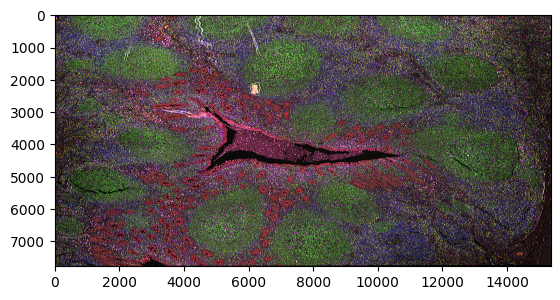

In [23]:
out_dir = generate_composite_images(
    path_raw=path_raw,
    path_out_root=path_img,
    selected_markers=state["selected_markers"],
    marker_to_hex=state["marker_to_hex"],
)
